Using precomputed R_curve (MODE='scale'). Set RUN_R_CURVE=True to recompute.

beta     R(beta)        C_eff=c0/(beta R^2)     R*sqrt(beta)
 0.40   0.244882812     5.211148060         0.154877489
 0.80   0.145429687     7.387778810         0.130076267
 1.20   0.103867187     9.655438966         0.113780803
 1.60   0.081601563     11.732568028         0.103218719
 2.00   0.068242187     13.420668157         0.096509027
 2.40   0.057851563     15.562113730         0.089623255
 2.80   0.051171875     17.048623540         0.085626925
 3.20   0.045976562     18.479364830         0.082245375

C_fit (beta>=2.0) = 16.127693
C_safe = 20.159616   (safety multiplier 1.25x)



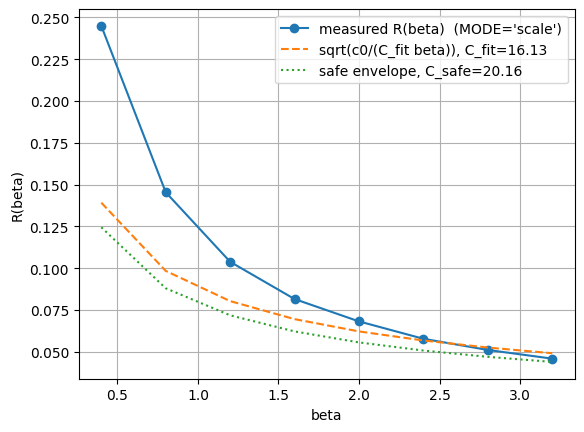

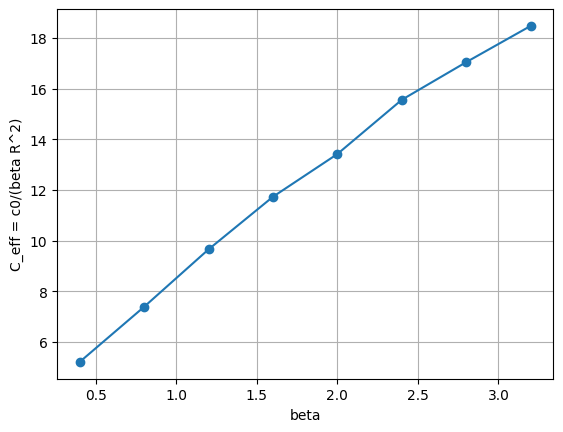

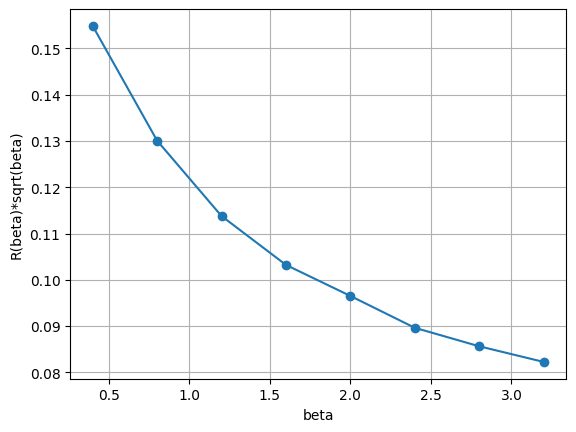


Flow test: beta=3.0, starting r0 = 3.0 * R(beta) = 0.145723  (R=0.048574)
Envelope uses r(t) = RMS(theta)



/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


t=0.000  r_env=0.145659  (r_rms=0.145659, r_max=0.635892)   lam_min=-0.368764   env_fit=-0.901525   Ceff(t)=7.758
t=0.010  r_env=0.141417  (r_rms=0.141417, r_max=0.618970)   lam_min=-0.342218   env_fit=-0.842600   Ceff(t)=7.787
t=0.020  r_env=0.137402  (r_rms=0.137402, r_max=0.602643)   lam_min=-0.303263   env_fit=-0.788443   Ceff(t)=7.561
t=0.030  r_env=0.133605  (r_rms=0.133605, r_max=0.586896)   lam_min=-0.296842   env_fit=-0.738658   Ceff(t)=7.877
t=0.040  r_env=0.130016  (r_rms=0.130016, r_max=0.571714)   lam_min=-0.255495   env_fit=-0.692881   Ceff(t)=7.503
t=0.050  r_env=0.126626  (r_rms=0.126626, r_max=0.557079)   lam_min=-0.230998   env_fit=-0.650778   Ceff(t)=7.401
t=0.060  r_env=0.123424  (r_rms=0.123424, r_max=0.542976)   lam_min=-0.223547   env_fit=-0.612039   Ceff(t)=7.627
t=0.070  r_env=0.120401  (r_rms=0.120401, r_max=0.529389)   lam_min=-0.192534   env_fit=-0.576382   Ceff(t)=7.301
t=0.080  r_env=0.117549  (r_rms=0.117549, r_max=0.516301)   lam_min=-0.176246   env_fit=

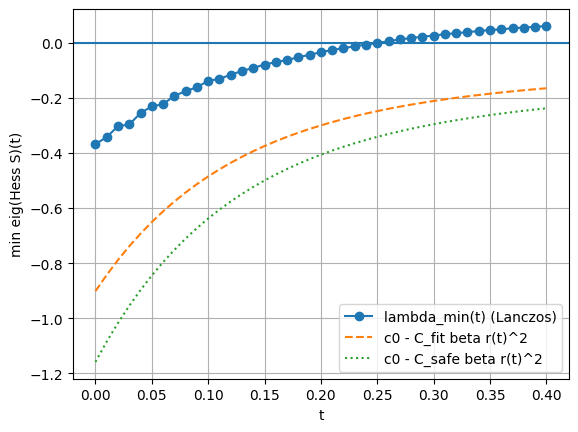

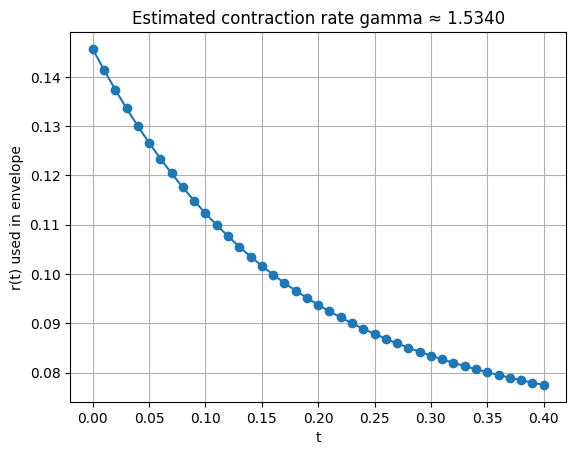

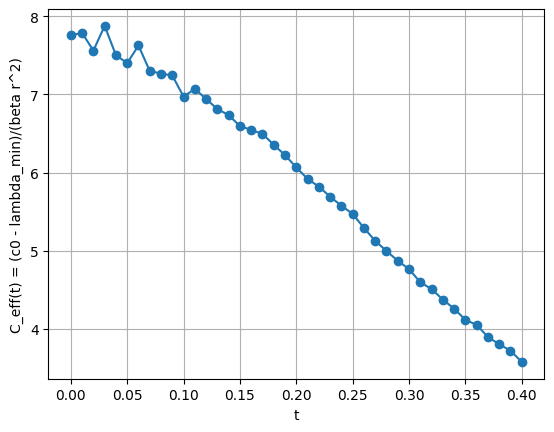

gamma_est ≈ 1.533981  from least-squares fit of log r(t)


In [1]:
# ============================================================
# SU(3) Wilson+Haar convexity + restoration logging (ONE CELL)
# ============================================================

# If you're on Colab GPU and JAX isn't installed with CUDA yet, uncomment ONE of these:
# !pip -q install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
# !pip -q install --upgrade jax jaxlib

import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.lax as lax
from functools import partial

jax.config.update("jax_enable_x64", False)

# -----------------------
# Knobs you’ll actually touch
# -----------------------
L = 8
c0 = 0.125

betas = np.array([0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2], dtype=np.float32)

# MODE:
#   "scale" reproduces your existing scan where r := scale multiplier on N(0,1).
#   "rmax" replaces "scale" with measured amplitude r := max_link ||A||_F in this chart.
MODE = "scale"   # change to "rmax" for the cleaner proof-aligned scan

# Convexity scan settings
RUN_R_CURVE = False  # set True to recompute R(beta); False uses your precomputed curve (scale-mode only)
n_samples   = 6
lanczos_k   = 25
bisect_iters= 12
tol_R       = 1e-3
seed_base   = 0

# Flow logging settings
beta_flow       = 3.0
FLOW_INIT_FACTOR= 3.0     # start at r0 = factor * R(beta_flow) (in the same "r" used by MODE)
flow_dt         = 0.005
flow_steps      = 80
measure_every   = 2

# Tail region to fit C (edit as you like)
C_FIT_BETA_MIN = 2.0
C_SAFETY_MULT  = 1.25     # "theorem-safe" blunt envelope multiplier

# -----------------------
# Small helper: robust remat/checkpoint (for JAX version differences)
# -----------------------
remat = getattr(jax, "checkpoint", jax.remat)

# -----------------------
# SU(3) generators: T_a = (i/2) λ_a  (anti-Hermitian)
# -----------------------
def su3_generators():
    zero = 0.0
    one  = 1.0
    i    = 1.0j
    lam1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=jnp.complex64)
    lam2 = jnp.array([[0,-i,0],[i,0,0],[0,0,0]], dtype=jnp.complex64)
    lam3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=jnp.complex64)
    lam4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=jnp.complex64)
    lam5 = jnp.array([[0,0,-i],[0,0,0],[i,0,0]], dtype=jnp.complex64)
    lam6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=jnp.complex64)
    lam7 = jnp.array([[0,0,0],[0,0,-i],[0,i,0]], dtype=jnp.complex64)
    lam8 = (1.0/jnp.sqrt(3.0))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=jnp.complex64)
    lam  = jnp.stack([lam1,lam2,lam3,lam4,lam5,lam6,lam7,lam8], axis=0)
    T    = 0.5j * lam
    return T

T_SU3 = su3_generators()  # (8,3,3)

def su3_alg_from_vec(a8):
    # a8: (...,8) real
    return jnp.einsum("...a,aij->...ij", a8, T_SU3)

@remat
def su3_exp_pade22(A):
    # Pade (2,2): exp(A) ≈ (I + A/2 + A^2/12) (I - A/2 + A^2/12)^{-1}
    I  = jnp.eye(3, dtype=A.dtype)
    A2 = A @ A
    c1 = 0.5
    c2 = 1.0/12.0
    Num = I + c1*A + c2*A2
    Den = I - c1*A + c2*A2
    return jnp.linalg.solve(Den, Num)

def build_links_factory(L):
    @jax.jit
    def build_links(params):
        # params: (L,L,L,L,4,8) real
        flatA = params.reshape(-1, 8)
        A     = su3_alg_from_vec(flatA)          # (N,3,3)
        U     = jax.vmap(su3_exp_pade22)(A)      # (N,3,3)
        return U.reshape((L,L,L,L,4,3,3))
    return build_links

@jax.jit
def plaquette_sum(U, beta):
    # U: (L,L,L,L,4,3,3) complex
    S = jnp.array(0.0, dtype=jnp.float32)
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :, :]
            U_nu = U[..., nu, :, :]

            U_nu_shift = jnp.roll(U_nu, shift=-1, axis=mu)
            U_mu_shift = jnp.roll(U_mu, shift=-1, axis=nu)

            P = U_mu @ U_nu_shift @ jnp.conj(jnp.swapaxes(U_mu_shift, -1, -2)) @ jnp.conj(jnp.swapaxes(U_nu, -1, -2))
            trP = jnp.real(jnp.einsum("...ii->...", P))
            S = S + jnp.sum(1.0 - trP/3.0)
    return beta * S

@jax.jit
def haar_mass_flat(theta, c0):
    # With T_a=(i/2)λ_a and Tr(λ_a λ_b)=2δ_ab, one has Tr(A†A)=(1/2)||a||^2.
    # So sum_links c0 Tr(A†A) = (c0/2) sum(theta^2).
    return 0.5 * c0 * jnp.sum(theta * theta)

def make_ops(L, beta, c0):
    build_links = build_links_factory(L)

    def unflatten(theta):
        return theta.reshape((L,L,L,L,4,8))

    @jax.jit
    def action(theta):
        params = unflatten(theta)
        U      = build_links(params)
        return plaquette_sum(U, beta) + haar_mass_flat(theta, c0)

    grad_f = jax.grad(action)

    @jax.jit
    def grad_action(theta):
        return grad_f(theta)

    @jax.jit
    def hvp(theta, v):
        return jax.jvp(grad_f, (theta,), (v,))[1]

    return action, grad_action, hvp

def lanczos_min(hvp, theta, k=25, seed=0):
    key = jax.random.PRNGKey(seed)
    n   = theta.shape[0]
    v0  = jax.random.normal(key, (n,), dtype=theta.dtype)
    v0  = v0 / (jnp.linalg.norm(v0) + 1e-12)

    def step(carry, _):
        v_prev, v, beta_prev = carry
        w = hvp(theta, v)
        w = w - beta_prev * v_prev
        alpha = jnp.vdot(v, w).real
        w = w - alpha * v
        beta = jnp.linalg.norm(w)
        v_next = w / (beta + 1e-12)
        return (v, v_next, beta), (alpha, beta)

    init = (jnp.zeros_like(v0), v0, jnp.array(0.0, dtype=theta.dtype))
    _, (alphas, betas) = lax.scan(step, init, xs=None, length=k)

    T = jnp.zeros((k,k), dtype=jnp.float32)
    T = T.at[jnp.arange(k), jnp.arange(k)].set(alphas.astype(jnp.float32))
    off = betas[:-1].astype(jnp.float32)
    T = T.at[jnp.arange(k-1), jnp.arange(1,k)].set(off)
    T = T.at[jnp.arange(1,k), jnp.arange(k-1)].set(off)

    evals = jnp.linalg.eigvalsh(T)
    return float(evals[0])

# -----------------------
# Amplitude statistics r(theta)
# -----------------------
def r_rms(theta):
    return float(jnp.sqrt(jnp.mean(theta*theta)))

def r_max_link_fro(theta):
    a = theta.reshape(-1, 8)
    # Tr(A†A)=(1/2)||a||^2 in this normalization
    link_sq = 0.5 * jnp.sum(a*a, axis=1)
    return float(jnp.sqrt(jnp.max(link_sq)))

# The r used in the erosion law depends on MODE:
# - scale-mode: use RMS so it matches the “scale” you scan with (and is well-defined along flow)
# - rmax-mode: use max-link Frobenius norm (more proof-aligned)
def r_for_envelope(theta):
    return r_rms(theta) if MODE == "scale" else r_max_link_fro(theta)

# -----------------------
# Sampling at fixed "r"
# -----------------------
def sample_theta(L, r_value, key):
    shape = (L,L,L,L,4,8)
    z = jax.random.normal(key, shape, dtype=jnp.float32).reshape(-1)

    if MODE == "scale":
        return (r_value * z).astype(jnp.float32)

    # MODE == "rmax": rescale to hit r_max_link_fro(theta) == r_value
    r0 = r_max_link_fro(z)
    scale = r_value / (r0 + 1e-12)
    return (scale * z).astype(jnp.float32)

def worst_lambda_min(hvp, beta, r_value, n_samples, seed0=0):
    key = jax.random.PRNGKey(seed0)
    worst = +1e9
    worst_r = None
    for i in range(n_samples):
        key, sub = jax.random.split(key)
        theta = sample_theta(L, float(r_value), sub)
        lam   = lanczos_min(hvp, theta, k=lanczos_k, seed=seed0 + 1000*i)
        worst = min(worst, lam)
        worst_r = r_for_envelope(theta)  # just to sanity-check scale/r alignment
    return worst

def detect_R_beta(beta, c0):
    action, grad_action, hvp = make_ops(L, float(beta), float(c0))

    # Find a bracket [lo,hi] with lo stable and hi unstable
    lo = 0.02
    hi = 0.40
    lam_lo = worst_lambda_min(hvp, beta, lo, n_samples, seed0=seed_base + int(100*beta))
    if lam_lo <= 0.0:
        raise RuntimeError(f"Even lo={lo} unstable at beta={beta}. Decrease lo.")

    lam_hi = worst_lambda_min(hvp, beta, hi, n_samples, seed0=seed_base + int(100*beta) + 1)
    while lam_hi > 0.0 and hi < 2.0:
        hi *= 1.5
        lam_hi = worst_lambda_min(hvp, beta, hi, n_samples, seed0=seed_base + int(100*beta) + 2)

    if lam_hi > 0.0:
        print(f"[warn] beta={beta}: still stable at hi={hi:.3f}. Returning hi as lower bound.")
        return float(hi)

    # Bisection
    for _ in range(bisect_iters):
        mid = 0.5*(lo+hi)
        lam_mid = worst_lambda_min(hvp, beta, mid, n_samples, seed0=seed_base + int(100*beta) + 3)
        if lam_mid > 0.0:
            lo = mid
        else:
            hi = mid
        if (hi - lo) < tol_R:
            break
    return float(lo)

# -----------------------
# (Optional) R(beta) scan
# -----------------------
R_curve = None

if (not RUN_R_CURVE) and (MODE == "scale"):
    # Your precomputed curve (scale-mode)
    R_curve = [
        (0.4, 0.2448828125),
        (0.8, 0.1454296875),
        (1.2, 0.1038671875),
        (1.6, 0.0816015625),
        (2.0, 0.0682421875),
        (2.4, 0.0578515625),
        (2.8, 0.051171875),
        (3.2, 0.0459765625),
    ]
    print("Using precomputed R_curve (MODE='scale'). Set RUN_R_CURVE=True to recompute.\n")
else:
    print(f"Computing R(beta) curve with MODE='{MODE}' ...\n")
    t0 = time.time()
    R_curve = []
    for b in betas:
        Rb = detect_R_beta(float(b), c0)
        R_curve.append((float(b), float(Rb)))
        print(f"beta={float(b):.3f}  R(beta)≈{Rb:.6f}")
    print(f"\nDone. Total wall time: {time.time()-t0:.2f}s\n")

# -----------------------
# Fit C and plot diagnostics
# -----------------------
betas_np = np.array([b for b,_ in R_curve], dtype=np.float64)
R_np     = np.array([r for _,r in R_curve], dtype=np.float64)

C_eff = c0 / (betas_np * R_np**2)
K     = R_np * np.sqrt(betas_np)

mask  = betas_np >= C_FIT_BETA_MIN
C_fit = float(C_eff[mask].mean())
C_safe= float(C_SAFETY_MULT * C_fit)

print("beta     R(beta)        C_eff=c0/(beta R^2)     R*sqrt(beta)")
for b,r,ce,k in zip(betas_np, R_np, C_eff, K):
    print(f"{b:5.2f}   {r:0.9f}     {ce:0.9f}         {k:0.9f}")

print(f"\nC_fit (beta>={C_FIT_BETA_MIN}) = {C_fit:.6f}")
print(f"C_safe = {C_safe:.6f}   (safety multiplier {C_SAFETY_MULT}x)\n")

def R_model(beta, C):
    return np.sqrt(c0/(C*beta))

R_fit  = R_model(betas_np, C_fit)
R_safe = R_model(betas_np, C_safe)

plt.figure()
plt.plot(betas_np, R_np, 'o-', label=f"measured R(beta)  (MODE='{MODE}')")
plt.plot(betas_np, R_fit, '--', label=f"sqrt(c0/(C_fit beta)), C_fit={C_fit:.2f}")
plt.plot(betas_np, R_safe, ':', label=f"safe envelope, C_safe={C_safe:.2f}")
plt.xlabel("beta"); plt.ylabel("R(beta)")
plt.grid(True); plt.legend(); plt.show()

plt.figure()
plt.plot(betas_np, C_eff, 'o-')
plt.xlabel("beta"); plt.ylabel("C_eff = c0/(beta R^2)")
plt.grid(True); plt.show()

plt.figure()
plt.plot(betas_np, K, 'o-')
plt.xlabel("beta"); plt.ylabel("R(beta)*sqrt(beta)")
plt.grid(True); plt.show()

# -----------------------
# Restoration flow: log r_t and test lambda_min(t) vs c0 - C beta r_t^2
# -----------------------
def interp_R(beta_query):
    return float(np.interp(beta_query, betas_np, R_np))

R0 = interp_R(beta_flow)
r0 = FLOW_INIT_FACTOR * R0

print(f"\nFlow test: beta={beta_flow}, starting r0 = {FLOW_INIT_FACTOR} * R(beta) = {r0:.6f}  (R={R0:.6f})")
print(f"Envelope uses r(t) = {'RMS(theta)' if MODE=='scale' else 'max_link ||A||_F'}\n")

action_f, grad_action, hvp = make_ops(L, float(beta_flow), float(c0))

# init theta at prescribed r0 (scale or rmax depending on MODE)
theta = sample_theta(L, float(r0), jax.random.PRNGKey(4242))

@jax.jit
def flow_step(theta):
    return theta - flow_dt * grad_action(theta)

ts, rs_env, rs_rms, rs_max, lams, env_fit, env_safe, ceffs = [], [], [], [], [], [], [], []

t_start = time.time()
for step in range(flow_steps+1):
    if step % measure_every == 0:
        t = step * flow_dt
        lam = lanczos_min(hvp, theta, k=lanczos_k, seed=777 + step)
        rrms = r_rms(theta)
        rmax = r_max_link_fro(theta)
        rE   = r_for_envelope(theta)

        env1 = c0 - C_fit  * beta_flow * (rE**2)
        env2 = c0 - C_safe * beta_flow * (rE**2)

        # empirical C_eff(t) from trajectory (avoid division by 0)
        if rE > 1e-12:
            ce_t = (c0 - lam)/(beta_flow * rE**2)
        else:
            ce_t = np.nan

        ts.append(t); rs_env.append(rE); rs_rms.append(rrms); rs_max.append(rmax)
        lams.append(lam); env_fit.append(env1); env_safe.append(env2); ceffs.append(ce_t)

        print(f"t={t:0.3f}  r_env={rE:0.6f}  (r_rms={rrms:0.6f}, r_max={rmax:0.6f})"
              f"   lam_min={lam: .6f}   env_fit={env1: .6f}   Ceff(t)={ce_t:0.3f}")

    theta = flow_step(theta)

print(f"\nFlow logging done. Wall time: {time.time()-t_start:.2f}s\n")

ts = np.array(ts)
rs_env = np.array(rs_env)
lams = np.array(lams)
env_fit = np.array(env_fit)
env_safe = np.array(env_safe)
ceffs = np.array(ceffs)

# Estimate gamma from log r(t) ~ log r0 - gamma t, using points where r is positive
mask = (rs_env > 0) & np.isfinite(rs_env)
if mask.sum() >= 3:
    X = np.vstack([ts[mask], np.ones(mask.sum())]).T
    y = np.log(rs_env[mask])
    slope, intercept = np.linalg.lstsq(X, y, rcond=None)[0]
    gamma_est = float(-slope)
else:
    gamma_est = float("nan")

plt.figure()
plt.plot(ts, lams, 'o-', label='lambda_min(t) (Lanczos)')
plt.plot(ts, env_fit, '--', label='c0 - C_fit beta r(t)^2')
plt.plot(ts, env_safe, ':', label='c0 - C_safe beta r(t)^2')
plt.axhline(0.0)
plt.xlabel("t"); plt.ylabel("min eig(Hess S)(t)")
plt.grid(True); plt.legend(); plt.show()

plt.figure()
plt.plot(ts, rs_env, 'o-')
plt.xlabel("t"); plt.ylabel("r(t) used in envelope")
plt.grid(True)
plt.title(f"Estimated contraction rate gamma ≈ {gamma_est:0.4f}")
plt.show()

plt.figure()
plt.plot(ts, ceffs, 'o-')
plt.xlabel("t"); plt.ylabel("C_eff(t) = (c0 - lambda_min)/(beta r^2)")
plt.grid(True); plt.show()

print(f"gamma_est ≈ {gamma_est:0.6f}  from least-squares fit of log r(t)")